In [1]:
import sys
import os
import warnings
import time
import inspect
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Addthe parent directory to the system path to access the 'src' module.
# Assuming this notebook resides in 'notebooks/', '..' resolves to the project root.
sys.path.append(os.path.abspath('..'))

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

train_path = "../data/train.csv"
test_path = "../data/test.csv"

def load_data(path):
    data = pd.read_csv(path)
    return data

df = load_data(train_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


In [2]:
test_df = load_data(test_path)
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.500,0,0,330911,7.829,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.000,1,0,363272,7.000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.000,0,0,240276,9.688,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.000,0,0,315154,8.662,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.000,1,1,3101298,12.287,NaN,S


In [3]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Info #####################")
    print(dataframe.info())
    print("##################### Types #####################")
    display(dataframe.dtypes.to_frame("Type"))
    print("##################### Head #####################")
    display(dataframe.head(head))
    print("##################### Tail #####################")
    display(dataframe.tail(head))
    print("##################### Describe #####################")
    display(dataframe.describe([0, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1]).T)
    print("\n###################### Unique Value Counts per Column ######################")
    display(dataframe[dataframe.columns].nunique())
    print("##################### NA #####################")
    display(dataframe.isnull().sum().to_frame("Missing Values"))

check_df(df)

##################### Shape #####################
(891, 12)
##################### Info #####################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
##################### Types #####################


,Type
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


##################### Head #####################


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


##################### Tail #####################


...

,count,mean,std,min,0%,5%,25%,50%,75%,95%,99%,100%,max
PassengerId,891.000,446.000,257.354,1.000,1.000,45.500,223.500,446.000,668.500,846.500,882.100,891.000,891.000
Survived,891.000,0.384,0.487,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000
Pclass,891.000,2.309,0.836,1.000,1.000,1.000,2.000,3.000,3.000,3.000,3.000,3.000,3.000
Age,714.000,29.699,14.526,0.420,0.420,4.000,20.125,28.000,38.000,56.000,65.870,80.000,80.000
SibSp,891.000,0.523,1.103,0.000,0.000,0.000,0.000,0.000,1.000,3.000,5.000,8.000,8.000
Parch,891.000,0.382,0.806,0.000,0.000,0.000,0.000,0.000,0.000,2.000,4.000,6.000,6.000
Fare,891.000,32.204,49.693,0.000,0.000,7.225,7.910,14.454,31.000,112.079,249.006,512.329,512.329



###################### Unique Value Counts per Column ######################


PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

##################### NA #####################


,Missing Values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Returns the names of categorical, numerical, and categorical but cardinal columns in the dataset.
    
    Note: Categorical columns also include those that are numerically-coded but categorical in nature.
    
    Parameters
    ----------
        dataframe: pandas.DataFrame
                The dataframe from which the column names are to be extracted.
        cat_th: int, optional
                The threshold for the number of unique values to classify a numerical column as categorical.
        car_th: int, optional
                The threshold for the number of unique values to classify a categorical column as cardinal.
    
    Returns
    -------
        cat_cols: list
                A list of the names of categorical columns.
        num_cols: list
                A list of the names of numerical columns.
        cat_but_car: list
                A list of the names of categorical columns that are considered cardinal.
        num_but_cat: list
                A list of the names of numerical columns that are considered categorical.
    
    Examples
    --------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))
    
    Notes
    -----
        - The sum of the lengths of cat_cols, num_cols, and cat_but_car equals the total number of columns.
        - Columns identified as "numeric but categorical" are included within the cat_cols list.
        - The total number of columns is equal to the sum of the lengths of the three returned lists: len(cat_cols) + len(num_cols) + len(cat_but_car).

    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() <= cat_th and dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car, num_but_cat

cat_cols, num_cols, cat_but_car, num_but_cat = grab_col_names(df)

num_cols = [col for col in num_cols if col not in "PassengerId"]

Observations: 891
Variables: 12
cat_cols: 6
num_cols: 3
cat_but_car: 3
num_but_cat: 4


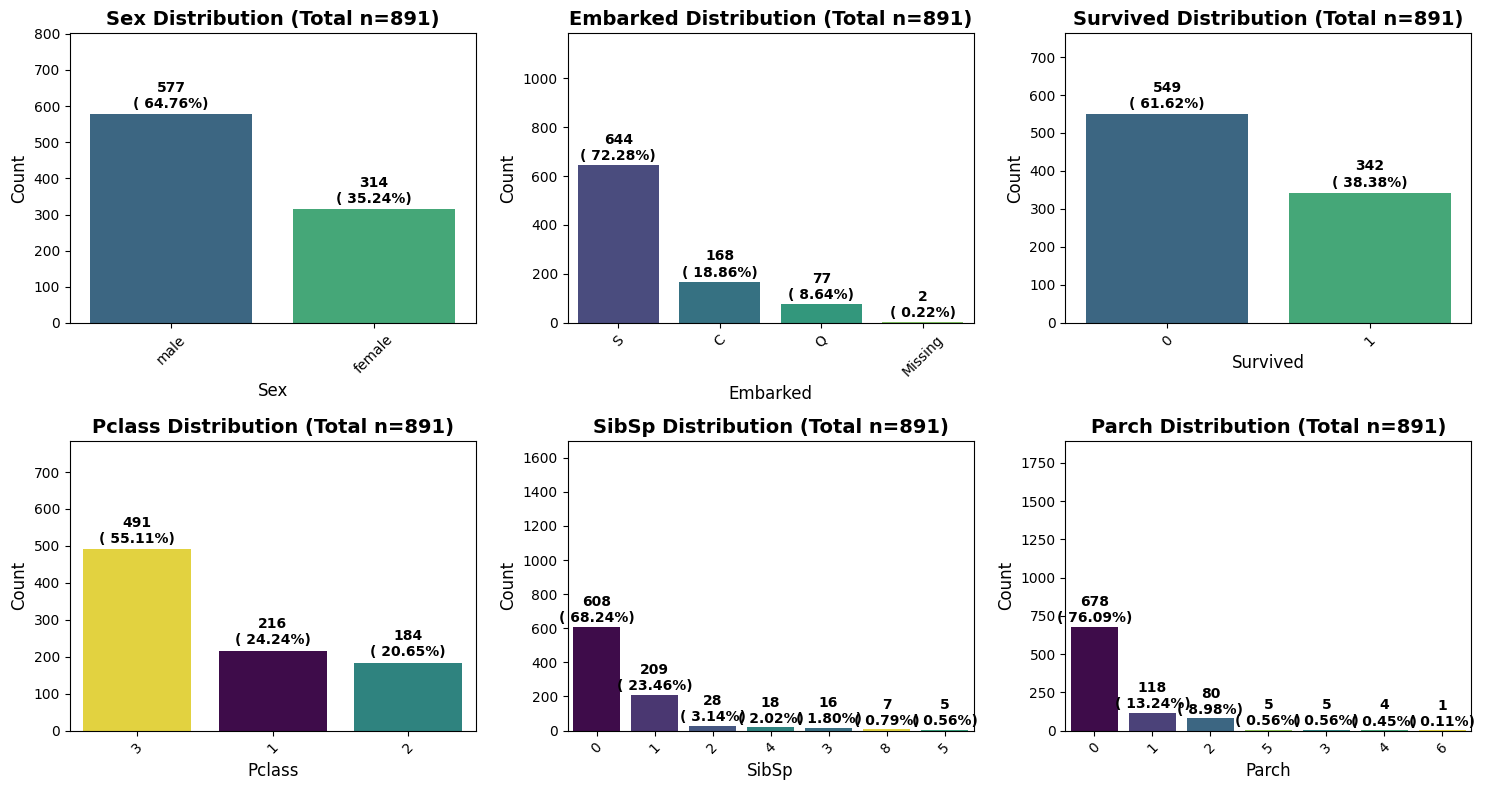

In [5]:
def cat_summary(dataframe, col_name, plot=False, ax=None):
    if dataframe[col_name].dtypes == "bool":
        dataframe[col_name] = dataframe[col_name].astype(int)
    value_counts = dataframe[col_name].value_counts(dropna=False)
    ratio = 1000 * value_counts / len(dataframe)
    summary_df = pd.DataFrame({col_name: value_counts, "Ratio:%": ratio.round(2)})
    n_missing = dataframe[col_name].isnull().sum()
    #print(f"\n{'#'*50}")
    #print(f"Column: {col_name}")
    #print(f"{'#'*50}")
    #print(summary_df,"\n")
    if n_missing > 0:
        #print(f"Column: {col_name} has missing rate: {n_missing} ({100*n_missing/len(dataframe):.2f}%)\n")
        pass
    if plot:
        plot_data = dataframe[[col_name]].copy()
        plot_data[col_name] = plot_data[col_name].fillna("Missing")
        order = plot_data[col_name].value_counts().index

        if ax is None:
            plt.figure(figsize=(12, 6))
            ax = plt.gca()

        sns.countplot(x=col_name, data=plot_data, order=order, hue=col_name, palette="viridis", legend=False, ax=ax)
        total = len(plot_data)
        for p in ax.patches:
            height = p.get_height()
            pct = 100 * height / total 
            ax.annotate(f"{int(height)}\n({pct: .2f}%)",
                       (p.get_x() + p.get_width() / 2., height + total * 0.01),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")
            ax.set_title(f"{col_name} Distribution (Total n={total})", fontsize=14, fontweight="bold")
            ax.set_xlabel(col_name, fontsize=12)
            ax.set_ylabel("Count", fontsize=12)
            ax.tick_params(axis="x", rotation=45)
            ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

            if ax is None:
                plt.tight_layout()
                plt.show(block=True)

# Display all graphs in a single plot
def plot_all_categories(dataframe, cat_cols, cols_per_row=3, save=False, filename="cat_summary.png"):
    n_cols = len(cat_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(cat_cols):
        cat_summary(dataframe, col, plot=True, ax=axes[idx])

    for idx in range(n_cols, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Plot saved: {filename}")

    plt.show()

plot_all_categories(df, cat_cols)   # Don't save
# plot_all_categories(df, cat_cols, save=True)  # Save with default name
# plot_all_categories(df, cat_cols, save=True, filename="analyse.png")  # Save with special name

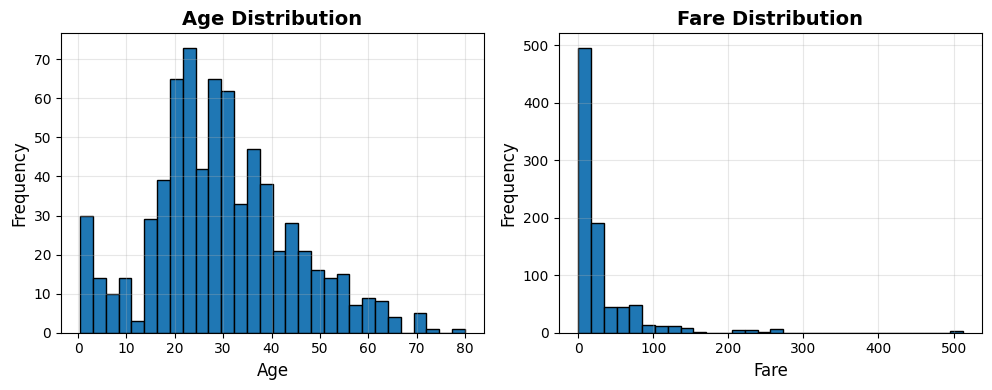

In [6]:
def num_summary(dataframe, numerical_col, plot=False, ax=None):
    missing_count = dataframe[numerical_col].isna().sum()
    missing_pct = 100 * missing_count / len(dataframe)
    #print("#######################################################")
    #print(f"Column: {numerical_col} \nMissing Value Count: {missing_count} \nMissing Value Percentage: {missing_pct:.2f}%\n")
    #quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    #print(dataframe[numerical_col].describe(quantiles).T, "\n")

    if plot:
        if ax is None:
            plt.figure(figsize=(10, 6))
            ax = plt.gca()

        dataframe[numerical_col].hist(ax=ax, bins=30, edgecolor="black")
        ax.set_xlabel(numerical_col, fontsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.set_title(f"{numerical_col} Distribution", fontsize=14, fontweight="bold")
        ax.grid(alpha=0.3)

        if ax is None:
            plt.tight_layout()
            plt.show(block=True)

# Display all graphs in a single plot
def plot_all_numerical(dataframe, num_cols, cols_per_row=3, save=False, filename="num_summary.png"):
    n_cols = len(num_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(num_cols):
        num_summary(dataframe, col, plot=True, ax=axes[idx])

    # Hide unused subplots
    for idx in range(n_cols, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Plot saved: {filename}")

    plt.show()

plot_all_numerical(df, num_cols)  # Don't save
# plot_all_numerical(df, num_cols, save=True)  # Save with default name
# plot_all_numerical(df, num_cols, cols_per_row=3, save=True, filename="numerical_analysis.png")  # Save with special name

In [ ]:
def target_summary_with_cat(dataframe, target, categorical_col):
    """
    Displays the target mean for each class of the categorical variable (including NaN).
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataframe to analyse the relationship between the categorical feature and the target feature.
    target : str
        Target feature ('Survived')
    categorical_col : str
        Categorical feature
    
    Examples
    --------
    target_summary_with_cat(df, "Survived", "Embarked")
    """
    # Temporarily fill NaNs with "Missing" (without altering the original data)
    temp_cat_col = dataframe[categorical_col].fillna("Missing")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = pd.DataFrame({
            "COUNT": temp_cat_col.value_counts(),
            "RATIO": 100 * temp_cat_col.value_counts() / len(dataframe),
            "TARGET_MEAN": dataframe.groupby(temp_cat_col)[target].mean(),
            "TARGET_MEDIAN": dataframe.groupby(temp_cat_col)[target].median()
        }).sort_values("TARGET_MEAN", ascending=False)
    print(f"\n{'='*70}")
    print(f"{categorical_col} → {target}")
    print(f"{'='*70}")
    print(result, "\n")

# For categorical variables (NaN values will appear as Missing)
for col in cat_cols:
    target_summary_with_cat(df, "Survived", col)


Sex → Survived
        COUNT  RATIO  TARGET_MEAN  TARGET_MEDIAN
Sex                                             
female    314 35.241        0.742          1.000
male      577 64.759        0.189          0.000 


Embarked → Survived
          COUNT  RATIO  TARGET_MEAN  TARGET_MEDIAN
Embarked                                          
Missing       2  0.224        1.000          1.000
C           168 18.855        0.554          1.000
Q            77  8.642        0.390          0.000
S           644 72.278        0.337          0.000 


Survived → Survived
          COUNT  RATIO  TARGET_MEAN  TARGET_MEDIAN
Survived                                          
1           342 38.384        1.000          1.000
0           549 61.616        0.000          0.000 


Pclass → Survived
        COUNT  RATIO  TARGET_MEAN  TARGET_MEDIAN
Pclass                                          
1         216 24.242        0.630          1.000
2         184 20.651        0.473          0.000
3         491 5

In [11]:
def target_summary_with_num(dataframe, target, numerical_col):
    """
    Displays descriptive statistics of a numerical variable grouped by the target variable.

    Since 'Survived' is binary (0 = did not survive, 1 = survived), we group
    directly by the target instead of trying to bin it into quartiles.
    This lets us compare, e.g., the age distribution of survivors vs. non-survivors.

    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataframe containing both the target and the numerical column.
    target : str
        Binary target variable (e.g. 'Survived': 0 or 1).
    numerical_col : str
        Numerical variable to summarise (e.g. 'Age', 'Fare').

    Examples
    --------
    target_summary_with_num(df, "Survived", "Age")
    """
    # Group by the binary target (0 / 1) and compute descriptive stats
    result = dataframe.groupby(target)[numerical_col].agg([
        ("COUNT",  "count"),
        ("MEAN",   "mean"),
        ("MEDIAN", "median"),
        ("STD",    "std"),
        ("MIN",    "min"),
        ("MAX",    "max")
    ]).round(2)

    print(f"\n{'='*70}")
    print(f"{numerical_col} by {target}  (0 = Did Not Survive, 1 = Survived)")
    print(f"{'='*70}")
    print(result)
    print()

# Compare each numerical variable across Survived = 0 and Survived = 1
for col in num_cols:
    target_summary_with_num(df, "Survived", col)


Age by Survived  (0 = Did Not Survive, 1 = Survived)
          COUNT   MEAN  MEDIAN    STD   MIN    MAX
Survived                                          
0           424 30.630  28.000 14.170 1.000 74.000
1           290 28.340  28.000 14.950 0.420 80.000


Fare by Survived  (0 = Did Not Survive, 1 = Survived)
          COUNT   MEAN  MEDIAN    STD   MIN     MAX
Survived                                           
0           549 22.120  10.500 31.390 0.000 263.000
1           342 48.400  26.000 66.600 0.000 512.330



Observations: 891
Variables: 12
cat_cols: 6
num_cols: 3
cat_but_car: 3
num_but_cat: 4


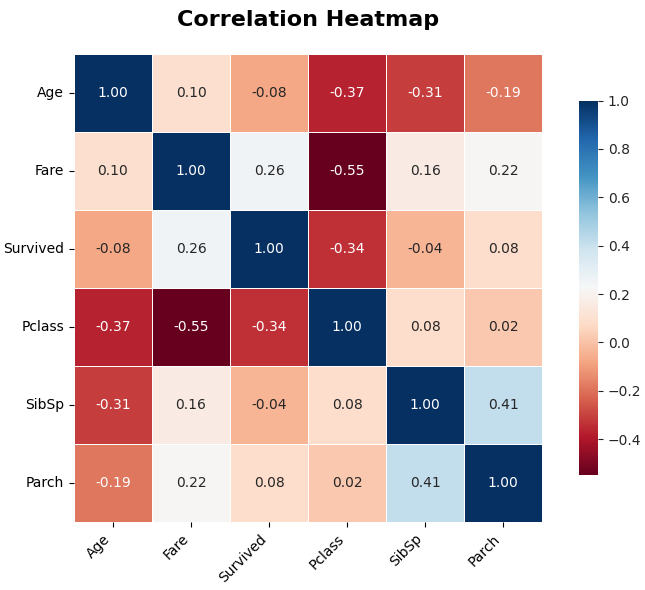

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Correlation Heatmap'}>,
             Age   Fare  Survived  Pclass  SibSp  Parch
 Age       1.000  0.096    -0.077  -0.369 -0.308 -0.189
 Fare      0.096  1.000     0.257  -0.549  0.160  0.216
 Survived -0.077  0.257     1.000  -0.338 -0.035  0.082
 Pclass   -0.369 -0.549    -0.338   1.000  0.083  0.018
 SibSp    -0.308  0.160    -0.035   0.083  1.000  0.415
 Parch    -0.189  0.216     0.082   0.018  0.415  1.000)

In [13]:
def plot_correlation_heatmap(dataframe,
                             columns=None,
                             figsize=(8, 6),
                             cmap="RdBu",
                             annot_format=".2f",
                             save=False,
                             filename="correlation_heatmap.png",
                             title=None):
    """
    Plots a correlation heatmap for numerical features.
    
    Parameters:
    -----------
    dataframe : pd.DataFrame
        Input dataframe
    columns : list, optional
        List of columns to include. If None, uses all numeric columns
    figsize : tuple, default (20, 20)
        Figure size (width, height)
    cmap : str, default "RdBu"
        Colourmap for heatmap (e.g., "RdBu", "coolwarm", "viridis")
    annot_format : str, default ".2f"
        Format for annotation values (e.g., ".2f", ".3f", ".1%")
    save : bool, default False
        Whether to save the figure
    filename : str, default "correlation_heatmap.png"
        Filename for saved figure (only used if save=True)
    title : str, optional
        Title for the plot. If None, uses default title
    
    Returns:
    --------
    tuple : (fig, ax, corr_matrix)
        Figure, axes, and correlation matrix
    """

    if columns is None:
        # Auto-detect numeric columns using grab_col_names
        _, numeric, _, numeric_but_cat = grab_col_names(dataframe)

        # Remove Id column
        numeric = [col for col in numeric if col not in ["PassengerId"]]

        # Include numeric but categorical columns
        columns = numeric + numeric_but_cat

    # Calculate correlation matrix
    corr_matrix = dataframe[columns].corr()

    # PLot
    fig, ax, = plt.subplots(figsize=figsize)

    with sns.axes_style("darkgrid"):
        sns.heatmap(corr_matrix,
                    annot=True,
                    fmt=annot_format,
                    cmap=cmap,
                    square=True,
                    linewidths=0.5,
                    cbar_kws={"shrink": 0.8},
                    ax=ax
                    )
        
    if title is None:
        title = "Correlation Heatmap"
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"The heatmap has been saved as: {filename}")

    plt.show()

    return fig, ax, corr_matrix

plot_correlation_heatmap(df)  # Don't save